# Laboratorio No 1

## Grupo Azul

---

### Daniel Felipe Sua Siempira
### Juan David Moreno D'Aleman

---

## 2. DESARROLLANDO: BÚSQUEDA SIN ADVERSARIO

### 2.1. A. MODELAR PROBLEMAS DE BÚSQUEDA

#### 2.1.1. Modelen las estructuras de datos auxiliares para implementar búsquedas en espacio de soluciones.

En base a la estructura dada en el enunciado, tenemos que finalizar la clase `Frontier`.

In [62]:
import heapq

class Node:
    def __init__(self, state, parent=None, action=None, cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.cost = cost

    def __str__(self):
        return f"Node(state={self.state}, action={self.action}, cost={self.cost})"

    def representation(self):
        return self.state

class Frontier:
    def __init__(self, evaluation_function):
        self.evaluation_function = evaluation_function
        self.frontierNode = []
        self.cont = 0

    def is_empty(self):
        return len(self.frontierNode) == 0

    def pop(self):
        if self.is_empty():
            raise Exception("empty frontier")
        delete = heapq.heappop(self.frontierNode)
        return delete[2]

    def top(self):
        if self.is_empty():
            raise Exception("empty frontier")
        top = self.frontierNode[0][2]
        return top

    def add(self, node):
        valor = self.evaluation_function(node)
        heapq.heappush(self.frontierNode, (valor, self.cont, node))
        self.cont += 1

Antes de empezar con la clase `Frontier`, en la clase `Node` creamos una ultima función para representar los nodos, esta unicamente devuelve su estado para que sea mas legible.

Para la clase `Frontier` le creamos una lista para guardar los nodos, sin embargo estos los guardamos en forma de tuplas, con 3 elementos, asi como un contador, este contador tiene la función de hacer de "indice" para la lista, ya que al ser una cola de prioridad basandose en el costo (por el momento no tomamos en cuenta la heuristica), en caso de que 2 nodos tengan el mismo coste, se elije por quien llego primero, para esto usamos el contador.

Por lo que las tuplas se crean en el orden `costo, contador, nodo`, para que primero compare el costo de ir a x nodo, en caso de ser igual se elegira por el quien llego o se leyo primero, o sea el contador, el cual al ser diferente para todos los elementos, siempre sera el elemento de desempate. Y finalmente nodo.

Para cada función en orden:

* `is_empty()` verifica si la lista de frontera esta vacia.
* `pop()` primero verifica si la lista no esta vacia, en caso de que si, lanza una excepción, si no esta elimina el primer elemento ya que es el de mayor prioridad o mejor dicho de menor costo.
* `top()` primero verifica si la lista no esta vacia, en caso de que si, lanza una excepción, si no este retorna el primer elemento, pero al ser una tupla y solo queremos el nodo, solo devolvemos la tercera posición de la tupla que es el nodo como tal.
* `add(node)` agrega el nodo y se ingresa en forma de tupla extrayendo unicamente su atributo de costo y asignandole su contador (indice). Una vez agregado se suma 1 el contador para un posible siguiente elemento.


---




### 2.1.2 Modelen la estructura de datos para un problema de búsqueda:

In [63]:
class Problem:
    def __init__(self, initial_state, goals, graph, heuristics):
        self.initial_state = initial_state
        self.goals = goals
        self.graph = graph
        self.heuristics = heuristics

    def is_goal(self, state):
        return state in self.goals

    def result_actions(self, state):
        actions = self.graph[state]

        return set(actions.keys())

    def action_cost(self, state, action, state_1):
        actions = self.graph[state]
        return actions[state_1]

    def heuristic(self, state):
        return self.heuristics[state]

Para la clase `Problem` creamos la clase para modelar la estructura de datos, en este caso decidimos usar un grafo, esto ya que es la estructura mas comun para este tipo de problemas, asi mismo, para el caso de usar un arbol no binario, ya tenemos definido el atributo padre, para este caso de un grafo el padre seria el nodo anterior.

En esta clase modelamos los atributos necesarios para resolver el problema: el estado 
inicial `initial`, la o las metas `goals`, la estructura de datos que representa el mundo 
(en este caso un grafo) `graph`, y una tabla de heurísticas precalculadas `heuristics`.

Los métodos creados son:

* **is_goal**: indica si un estado dado es una meta (está en `goals`).
* **result_actions**: devuelve el conjunto de estados a los que se puede llegar en un paso desde el estado dado (los vecinos en el grafo).
* **action_cost**: devuelve el costo (float) de moverse de un estado a otro.
* **heuristic**: devuelve el valor estimado (float) de qué tan cerca está un estado de la meta, según la tabla precalculada.

---

## 2.2. B. IMPLEMENTAR

### 2.2.1.Implemente el algoritmo de búsqueda del mejor primero:

In [64]:
# ============================================================
# 1. Represente el nodo de fallo del espacio de búsqueda
# ============================================================
    
FAIL = Node(None)

# ============================================================
# 2. Implemente la función para expandir nodos fronterizos
# ============================================================
def expand(problem, node):
    state = node.state
    neighbors = problem.result_actions(state)
    neighbors = list(neighbors)
    expansion = []
    for neighbor in neighbors:
        cost = problem.action_cost(state, neighbor, neighbor) + node.cost
        node_1 = Node(neighbor, node, neighbor, cost)
        expansion.append(node_1)

    return expansion

    
# ============================================================
# 3. Implemente el algoritmo de búsqueda del mejor primero (Best-First Search)
# ============================================================

def best_first_search(problem, evaluation_function):
    root_node = Node(problem.initial_state, None, None, 0)
    frontier = Frontier(evaluation_function)
    frontier.add(root_node)

    while not frontier.is_empty():
        current_node = frontier.pop()

        if problem.is_goal(current_node.state):
            return current_node

        for neighbor in expand(problem, current_node):
            frontier.add(neighbor)
    return FAIL

Para la implementación del nodo de fallo, entre las opciones que nos dio el profesor, se decidio que sea cuando un nodo sea no tenga un estado definido, o mejor dicho que sea como un nodo vacio o de estado `None`. 

para la función de expandir los nodos fronterizos `expand` definimos el estado y los vecinos los cuales guardamos en una lista, aqui creamos otra lista que sera la de expansion, esta guardara los nodos vecinos que tenemos (aqui tambien calculamos el costo de ir a cada vecino usando la funcion de `action_cost`).

para el algoritmo de GBST o greedy Best first search definimos el nodo raiz que es aquel que sera nuestro punto de partida para la busqieda, asi como traer los nodos de frontera, ahora aqui hacemos un ciclo que mientras la frontera no este vacia, vamos eliminando los nodos que vamos recorriendo ya que los estamos explorando, asi mismo, revisamos que ese nodo que estamos explorando sea un estado meta, en caso que no guardamos los vecinos de ese nodo a la frontera. En caso de no encontrar la meta retornamos que no se puede llegar.

---

### 2.2.2. Pruebe la implementación del algoritmo con el siguiente espacio de ejemplo:

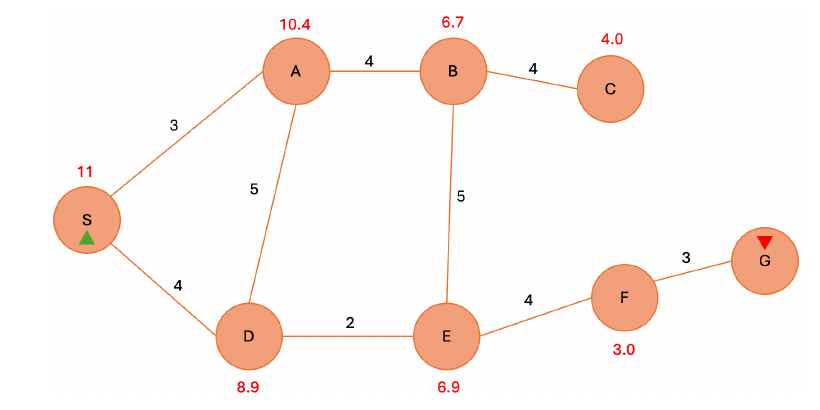

In [ ]:
# ============================================================
# 1. Implemente la función para visualizar la secuencia de acciones de un `Node`
# usando `Node.representation()`
# ============================================================

def path_actions(node):
    nodes = []
    while True:        
        nodes.append(node)        
        if node.parent == None:
            break
        node = node.parent

    nodes.reverse()

    actions = []
    for node in nodes:
        action = node.representation()
        actions.append(action)

    return actions

# ============================================================
# 2. Represent the example search problem
# ============================================================


initial = "S"
goals = {"G"}
graph = {
    "S": {"A": 3, "D": 4},
    "A": {"S": 3, "D": 5, "B": 4},
    "D": {"S": 4, "A": 5, "E": 2},
    "B": {"A": 4, "C": 4, "E": 5},
    "C": {"B": 4},
    "E": {"D": 2, "B": 5, "F": 4},
    "F": {"E": 4, "G": 3},
    "G": {"F": 3}
}
heuristics = {"S": 11, "A": 10.4, "D": 8.9, "B": 6.7, "E": 6.9, "C": 4.0, "F": 3.0, "G": 0}

problem = Problem(initial, goals, graph, heuristics)

# ============================================================
# 3. Use la implementación del algoritmo de búsqueda del mejor primero
# aplicándola al problema de búsqueda de ejemplo
# ============================================================


resultado = best_first_search(problem, lambda node: node.cost)

# ============================================================
# 4. Use la función para visualizar la secuencia de acciones
# con el resultado del algoritmo de búsqueda del mejor primero
# aplicado al problema de búsqueda de ejemplo
# ============================================================


solution = path_actions(resultado)
solution_visual = " -> ".join(solution)
print(solution_visual)

S -> D -> E -> F -> G


Ahora que tenemos un ejemplo conciso, podemos utilizar lo que ya habiamos creado antes, primero creamos una función para representar la secuencia de acciones de un `Node` usando `Node.representation()`. 

Luego, representamos el problema de búsqueda de ejemplo insertando el grafo, su estado inicial y final, y las heuristicas de cada punto o nodo asi como llamar la clase `Problem` para que lo modele.

Posteriormente, llamamos a `best_first_search` para que lo resulva.

Finalmente, visualizamos la secuencia de acciones resultante.

---

## 3. II. SOLUCIONAR PROBLEMAS

### 3.1.A. SOLUCIONANDO

#### 3.1.2. A.2 Problema del granjero

In [1]:
# ============================================================
# 1. Represente el diseño del problema seleccionado
# ============================================================

import heapq

class Node:
    def __init__(self, state, parent=None, action=None, cost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.cost = cost
    def __str__(self):
        return f"Node(state={self.state}, action={self.action}, cost={self.cost})"

    def representation(self):
        return self.state

class Frontier:
    def __init__(self, evaluation_function):
        self.evaluation_function = evaluation_function
        self.frontierNode = []
        self.cont = 0

    def is_empty(self):
        return len(self.frontierNode) == 0

    def pop(self):
        if self.is_empty():
            raise Exception("frontera vacia")
        delete = heapq.heappop(self.frontierNode)
        return delete[2]

    def top(self):
        if self.is_empty():
            raise Exception("frontera vacia")
        return self.frontierNode[0][2]

    def add(self, node):
        valor = self.evaluation_function(node)
        heapq.heappush(self.frontierNode, (valor, self.cont, node))
        self.cont += 1

# ============================================================
# 2. Agregue lo necesario a su representación del problema
# ============================================================

class Problem:
    def __init__(self, initial_state, goals):
        self.initial_state = initial_state
        self.goals = goals

    def is_goal(self, state):
        return state in self.goals

    def is_valid_state(self, state):
        if state[1] == state[2] and state[1] != state[0]:
            return False
        if state[2] == state[3] and state[2] != state[0]:
            return False
        return True

    def result_actions(self, state):
        coast_farmer = state[0]
        new_state = []
        if coast_farmer == state[1]:
            coast_change = list(state)
            coast_change[0] = 1 - coast_change[0]
            coast_change[1] = 1 - coast_change[1]
            if self.is_valid_state(coast_change):
                new_state.append(tuple(coast_change))

        if coast_farmer == state[2]:
            coast_change = list(state)
            coast_change[0] = 1 - coast_change[0]
            coast_change[2] = 1 - coast_change[2]
            if self.is_valid_state(coast_change):
                new_state.append(tuple(coast_change))

        if coast_farmer == state[3]:
            coast_change = list(state)
            coast_change[0] = 1 - coast_change[0]
            coast_change[3] = 1 - coast_change[3]
            if self.is_valid_state(coast_change):
                new_state.append(tuple(coast_change))

        coast_change = list(state)
        coast_change[0] = 1 - coast_change[0]
        if self.is_valid_state(coast_change):
            new_state.append(tuple(coast_change))
        return set(new_state)
        
            

    def action_cost(self, state, action, state_1):
        return 1

    def heuristic(self, state):
        return state.count(0)

FAIL = Node(None)

def expand(problem, node):
    state = node.state
    neighbors = problem.result_actions(state)
    neighbors = list(neighbors)
    expansion = []
    for neighbor in neighbors:
        cost = problem.action_cost(state, neighbor, neighbor) + node.cost
        node_1 = Node(neighbor, node, neighbor, cost)
        expansion.append(node_1)

    return expansion

# ============================================================
# 3. Use el algoritmo de búsqueda A*
# aplicándola al problema de seleccionado
# ============================================================

def best_first_search(problem, evaluation_function):
    root_node = Node(problem.initial_state, None, None, 0)
    frontier = Frontier(evaluation_function)
    frontier.add(root_node)

    while not frontier.is_empty():
        current_node = frontier.pop()

        if problem.is_goal(current_node.state):
            return current_node

        for neighbor in expand(problem, current_node):
            frontier.add(neighbor)
    return FAIL

# ============================================================
# 4. Use la función para visualizar la secuencia de acciones
# con el resultado del algoritmo de búsqueda A*
# aplicado al problema de búsqueda seleccionado
# ============================================================

def path_actions(node):
    nodes = []
    while True:        
        nodes.append(node)        
        if node.parent == None:
            break
        node = node.parent

    nodes.reverse()

    actions = []
    for node in nodes:
        action = node.state
        actions.append(action)

    return actions

initial = (0, 0, 0, 0)
goals = [(1, 1, 1, 1)]

problem = Problem(initial, goals)
result_node = best_first_search(problem, lambda node: node.cost + problem.heuristic(node.state))

solution_path = path_actions(result_node)
solution_path_str = " -> ".join(str(state) for state in solution_path)
print("Solution path:", solution_path_str)

Solution path: (0, 0, 0, 0) -> (1, 0, 1, 0) -> (0, 0, 1, 0) -> (1, 1, 1, 0) -> (0, 1, 0, 0) -> (1, 1, 0, 1) -> (0, 1, 0, 1) -> (1, 1, 1, 1)


Para este problema, gracias a la estructura utilizada previamente en el punto anterior, no se necesito cambiar gran cosa ya que era una plantilla que podia funcionar con cualquier problema de espacio de soluciones, ahora bien, para adaptar el problema, se cambio unicamente la clase `Problem` para que pudiera resolver este ejercicio.

Antes de todo, se utilizo una estructura de tupla para guardar los elemento `(G,L,O,W)` siendo G = Granjero, L = Lechuga, O = Oveja y W = Lobo, asi mismo, estos se representaban con `1` y `0` siendo `0` orilla izquierda y `1` orilla derecha.

Primero, se le cambio su constructor o `__init__` para que solo recibiera el esatdo inicial y la meta, `is_goal` se mantuvo igual, pero, se creo otra función nueva llamada `is_valid_state`, esta se encargaba de validar los estados de aceptación, osea decia si un estado era correcto o violaba una de las reglas dadas en el enunciado (por ejemplo que la oveja se quede con la lechuga).

Ahora, usando esto, reformulamos `result_actions` para que guarde los posibles movimientos que podemos realizar dependiendo el ganjero en que orilla este y con quienes este en esa misma orilla. Asi como, `action cost` fue simplificada a que solo retorne 1, esto ya que practicamente cruzar el rio no difiere de que lado se hace, osea el peso es el mismo, por lo que se deja de 1 por simplicidad.

Finalmente, la heuristica elegida y aprovada por el profe fue que como se uso una tupla de 1s y 0s, lo que se hace es contar la cantidad de elementos que estan en la orilla izquierda (osea contar la cantidad de 0s en la tupla), por lo qeu mientras mas elementos en la orilla derecha mas sube esta siemrpe y cuando no cometa ninguna violación de la reglas.

Por lo que, a la hora de llamar la función practicamente podemos utilizar la base del ejercicio anterior, eso incluye a `best_first_search` ya que auqnue se nos pide A*, `best_first_search` funciona para la parte de la heuristica, y unicamente le sumamos el peso del nodo para que tome la decisión (como solo hay 2 estados, que son de ida y vuelta, practicamente es `best_first_search`).

---

## 4.III. RETROSPECTIVA

1. ¿Cuál fue el tiempo total invertido en el laboratorio por cada uno de ustedes? (Horas/Hombre)

    Daniel Sua: 7 horas
    Juan Moreno: 7 horas

2. ¿Cuál es el estado actual del laboratorio? ¿Por qué?

    el estado del laboratorio es finalizado ya que logramos finalizar de manera satisfactoria todos los puntos asi como todos se encuantran correctos y explicados.

3. ¿Cuál consideran fue el mayor logro? ¿Por qué?

    el mayor logro fue entender y realizar el algoritmo de best first search ya que era la primera vez que lo aplicabamos en la realidad, asi como, ir construyendo paso a paso, cada parte para resolver cualquier espacio de soluciones, el cual nos sirvio para el ultimo punto.

4. ¿Cuál consideran que fue el mayor problema técnico? ¿Qué hicieron para resolverlo?

    el mayor problema tecnico fue recordar funciones de python ya que hace tiempo no trabajabamos con este lenguaje y teniamos temas olvidados, lo que nos demoro en recordar cosas y funciones utiles para eficiencia de tiempo.

5. ¿Qué hicieron bien como equipo? ¿Qué se comprometen a hacer para mejorar los resultados?

    hicimos bien en nuestra comunicación y colaboración entre nosotros, ya que nos manteniamos actualizados de lo que hacia el otro y como lo hizo. Y nos comprometemos a realizar los Laboratorios con mas tiempo y antelación.